# Cluster-Galaxy Clustering Analysis

Analysis of cluster-galaxy clustering as a function of redshift, richness, and galaxy type.

This notebook creates 4 types of plots:
1. Single redshift bin comparison of galaxy types
2. All richness bins with galaxy type comparison (1×3 grid)
3. Single redshift bin with richness comparison (2×2 grid)
4. Redshift evolution for each galaxy type (3 side-by-side panels)

## Configuration

Modify these settings to customize the plots.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path (go up one directory from notebooks/)
sys.path.insert(0, '../src')
from plotting_utils import *

# ===== CONFIGURATION SETTINGS =====

# Pipeline base directory
BASE_DIR = Path('../')

# Output directories for each galaxy type
output_dirs = {
    'all': BASE_DIR / 'outputs_rr2_redshift_richness_all',
    'early': BASE_DIR / 'outputs_rr2_redshift_richness_early',
    'late': BASE_DIR / 'outputs_rr2_redshift_richness_late'
}

# Redshift bins (matching your config files)
redshift_bins = [
    (0.1, 0.4),
    (0.4, 0.7),
    (0.7, 1.0),
    (1.0, 1.3),
    (1.3, 1.6),
    (1.6, 1.9)
]

# Richness bins (matching your config files)
richness_bins = [
    (40, 80),
    (80, 140),
    (140, 450)
]

# Plot settings
FONT_SIZE_MINOR = 15
FONT_SIZE_MAJOR = 20

# Default redshift bin for single-bin plots
DEFAULT_Z_BIN = (0.4, 0.7)  # Change this to select different redshift bin

# Output directory for plots (in notebooks folder)
PLOT_OUTPUT_DIR = Path('plots_galaxy_type_analysis')
PLOT_OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Configuration loaded successfully!")
print(f"Redshift bins: {len(redshift_bins)}")
print(f"Richness bins: {len(richness_bins)}")
print(f"Plots will be saved to: {PLOT_OUTPUT_DIR}")

# Check which directories have data
for gal_type, dir_path in output_dirs.items():
    if dir_path.exists():
        n_files = len(list(dir_path.glob('*.pkl')))
        print(f"  {gal_type}: {n_files} files")
    else:
        print(f"  {gal_type}: directory not found")

Configuration loaded successfully!
Redshift bins: 6
Richness bins: 3
Plots will be saved to: plots_galaxy_type_analysis
  all: 108 files
  early: 108 files
  late: 108 files


## Setup Plot Style

In [27]:
# Set up plot style
setup_plot_style(font_size_minor=FONT_SIZE_MINOR, font_size_major=FONT_SIZE_MAJOR)
print("Plot style configured with serif font")

Plot style configured with serif font


## Plot 1: Single Redshift Bin - Galaxy Type Comparison

Shows clustering for all three galaxy types (all, early, late) in a single redshift bin.

Saved: plot1_type_comparison_single_z.png


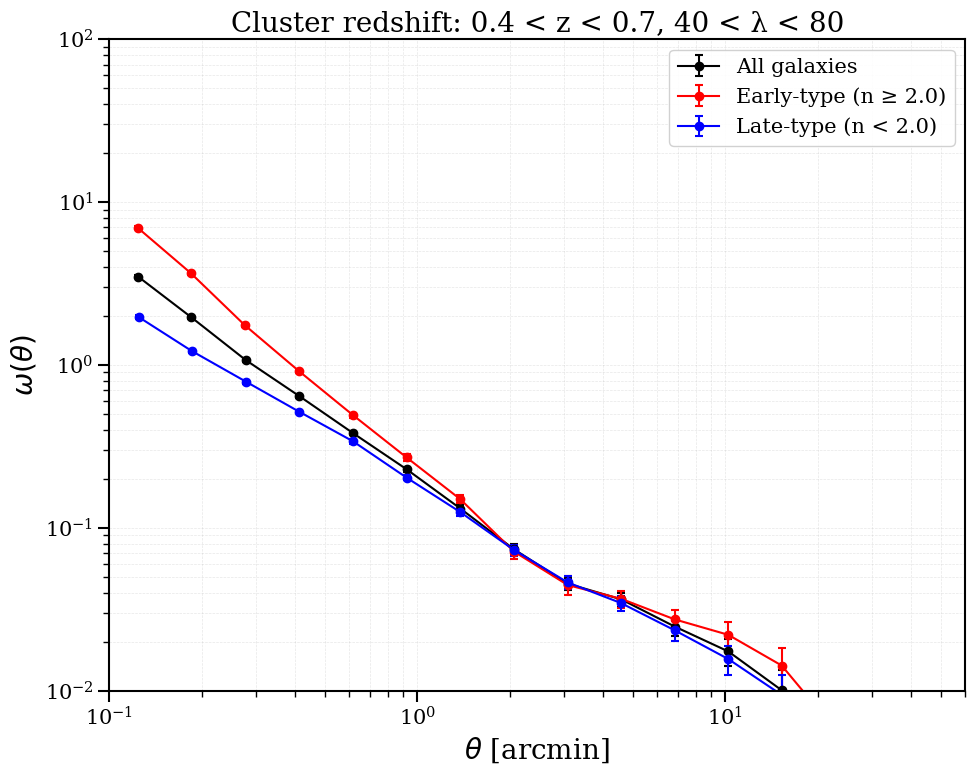

In [28]:
def plot_type_comparison_single_z(z_bin, richness_bin=None, output_file=None):
    """
    Plot galaxy type comparison for a single redshift bin.
    
    Parameters
    ----------
    z_bin : tuple
        Redshift bin (z_min, z_max)
    richness_bin : tuple, optional
        Richness bin (lambda_min, lambda_max)
    output_file : str, optional
        Output filename
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot each galaxy type
    for gal_type in ['all', 'early', 'late']:
        # Find result file
        files = find_result_files(
            output_dirs[gal_type],
            z_cluster_bin=z_bin,
            z_galaxy_bin=z_bin,
            richness_bin=richness_bin
        )
        
        if len(files) == 0:
            print(f"Warning: No results found for {gal_type} type")
            continue
        
        # Load results
        results = load_clustering_result(files[0])
        
        # Plot
        plot_correlation_function(
            ax, results['r'], results['xi'], results['sigma_xi'],
            label=get_galaxy_type_label(gal_type),
            color=get_galaxy_type_color(gal_type),
            marker='o', markersize=6
        )
    
    # Format axis
    format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
    
    # Add title
    title = f"Cluster redshift: {get_redshift_bin_label(*z_bin)}"
    if richness_bin is not None:
        title += f", {get_richness_bin_label(*richness_bin)}"
    ax.set_title(title)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plot for default redshift bin
plot_type_comparison_single_z(
    DEFAULT_Z_BIN,
    richness_bin=(40, 80),  # Use first richness bin
    output_file='plot1_type_comparison_single_z.png'
)

## Plot 2: All Richness Bins - Galaxy Type Comparison (1×3 Grid)

Shows 3 panels (one for each richness bin), each comparing the 3 galaxy types.

Saved: plot2_type_comparison_all_richness.png


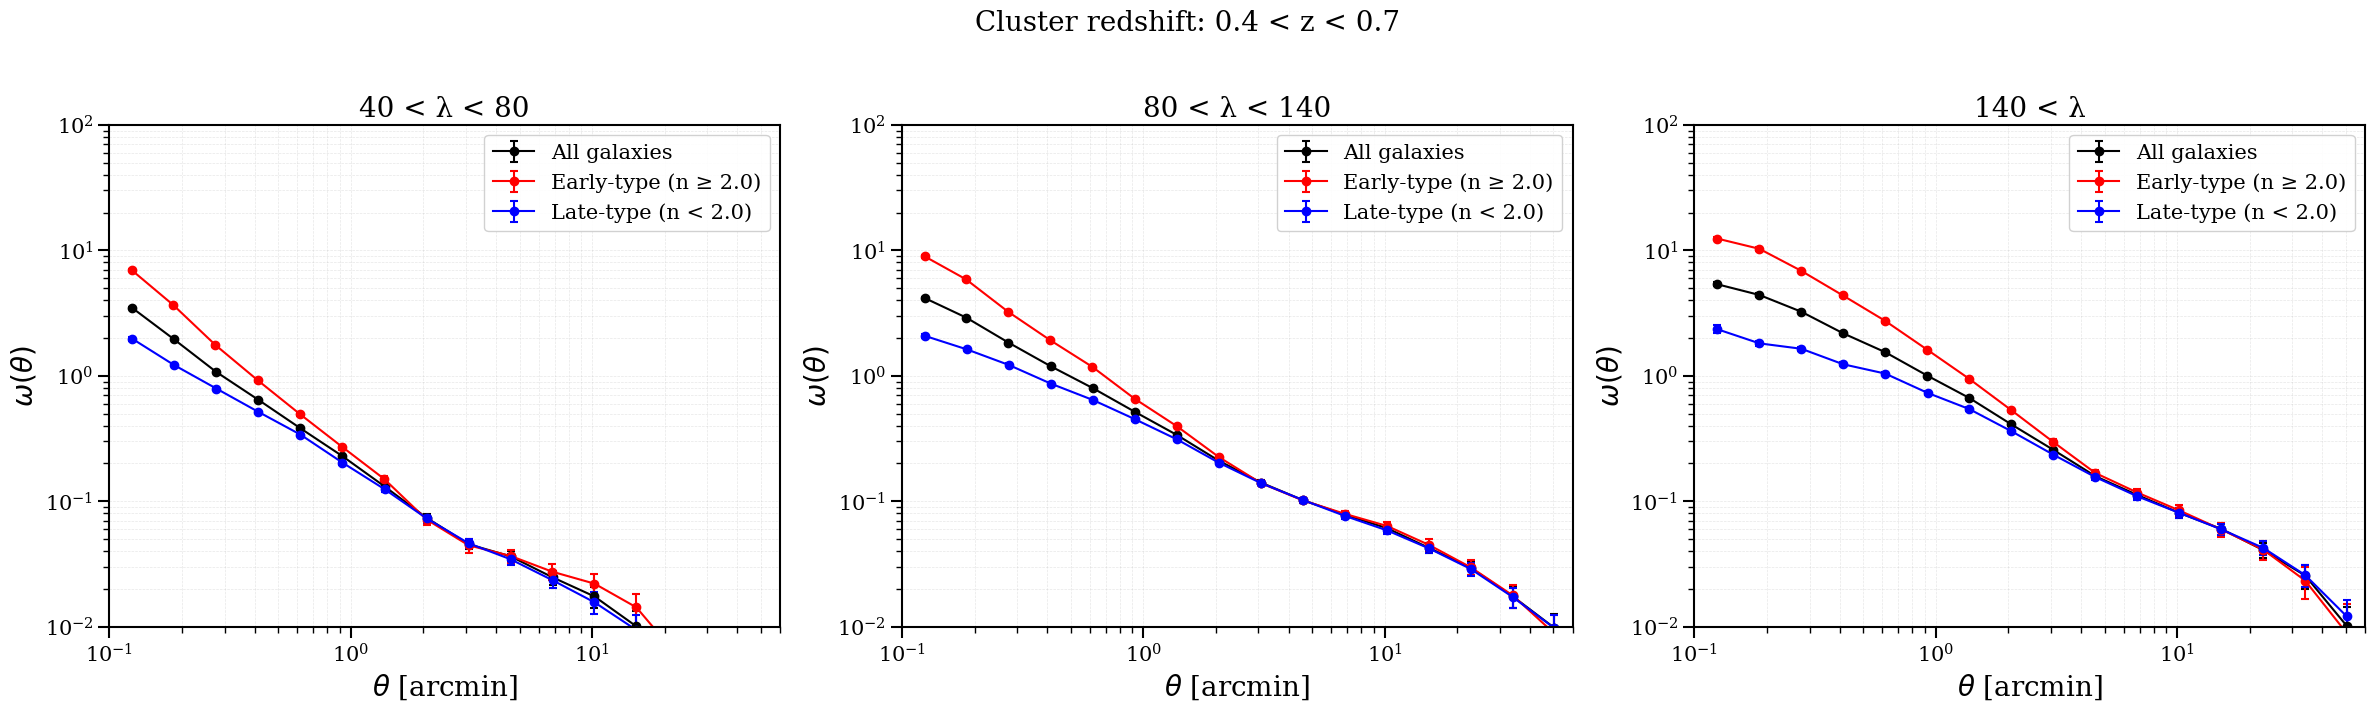

In [29]:
def plot_type_comparison_all_richness(z_bin, output_file=None):
    """
    Plot galaxy type comparison for all richness bins in a 1x3 grid.
    
    Parameters
    ----------
    z_bin : tuple
        Redshift bin (z_min, z_max)
    output_file : str, optional
        Output filename
    """
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    for i, richness_bin in enumerate(richness_bins):
        ax = axes[i]
        
        # Plot each galaxy type
        for gal_type in ['all', 'early', 'late']:
            # Find result file
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=z_bin,
                z_galaxy_bin=z_bin,
                richness_bin=richness_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot
            plot_correlation_function(
                ax, results['r'], results['xi'], results['sigma_xi'],
                label=get_galaxy_type_label(gal_type),
                color=get_galaxy_type_color(gal_type),
                marker='o', markersize=6
            )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        
        # Add subtitle
        ax.set_title(get_richness_bin_label(*richness_bin))
    
    # Overall title
    fig.suptitle(f"Cluster redshift: {get_redshift_bin_label(*z_bin)}", 
                 fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plot for default redshift bin
plot_type_comparison_all_richness(
    DEFAULT_Z_BIN,
    output_file='plot2_type_comparison_all_richness.png'
)

## Plot 3: Single Redshift Bin - Richness Comparison (2×2 Grid)

Shows 4 panels in 2×2 grid:
- Panel for each richness bin (3 panels)
- One comparison panel showing all richness bins together

Saved: plot3_richness_comparison_all.png


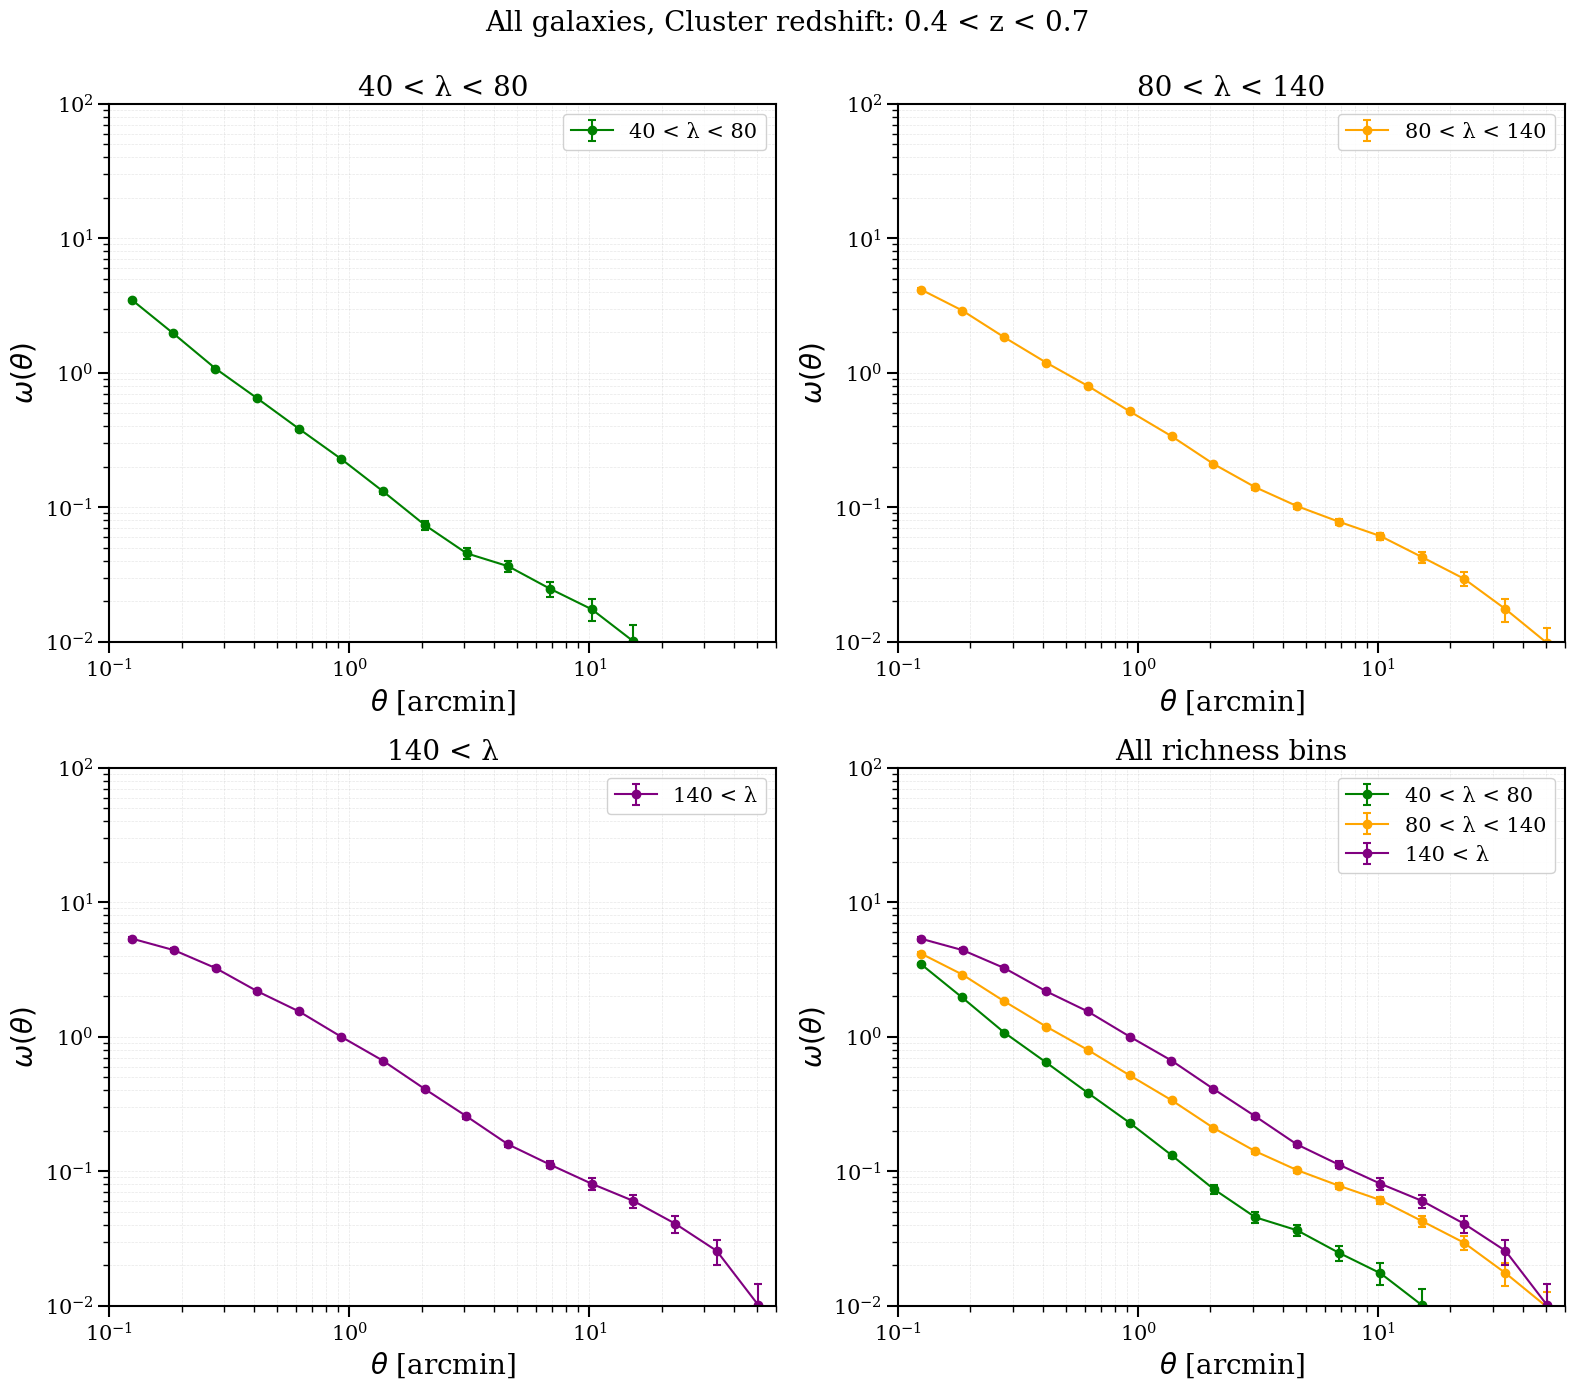

Saved: plot3_richness_comparison_early.png


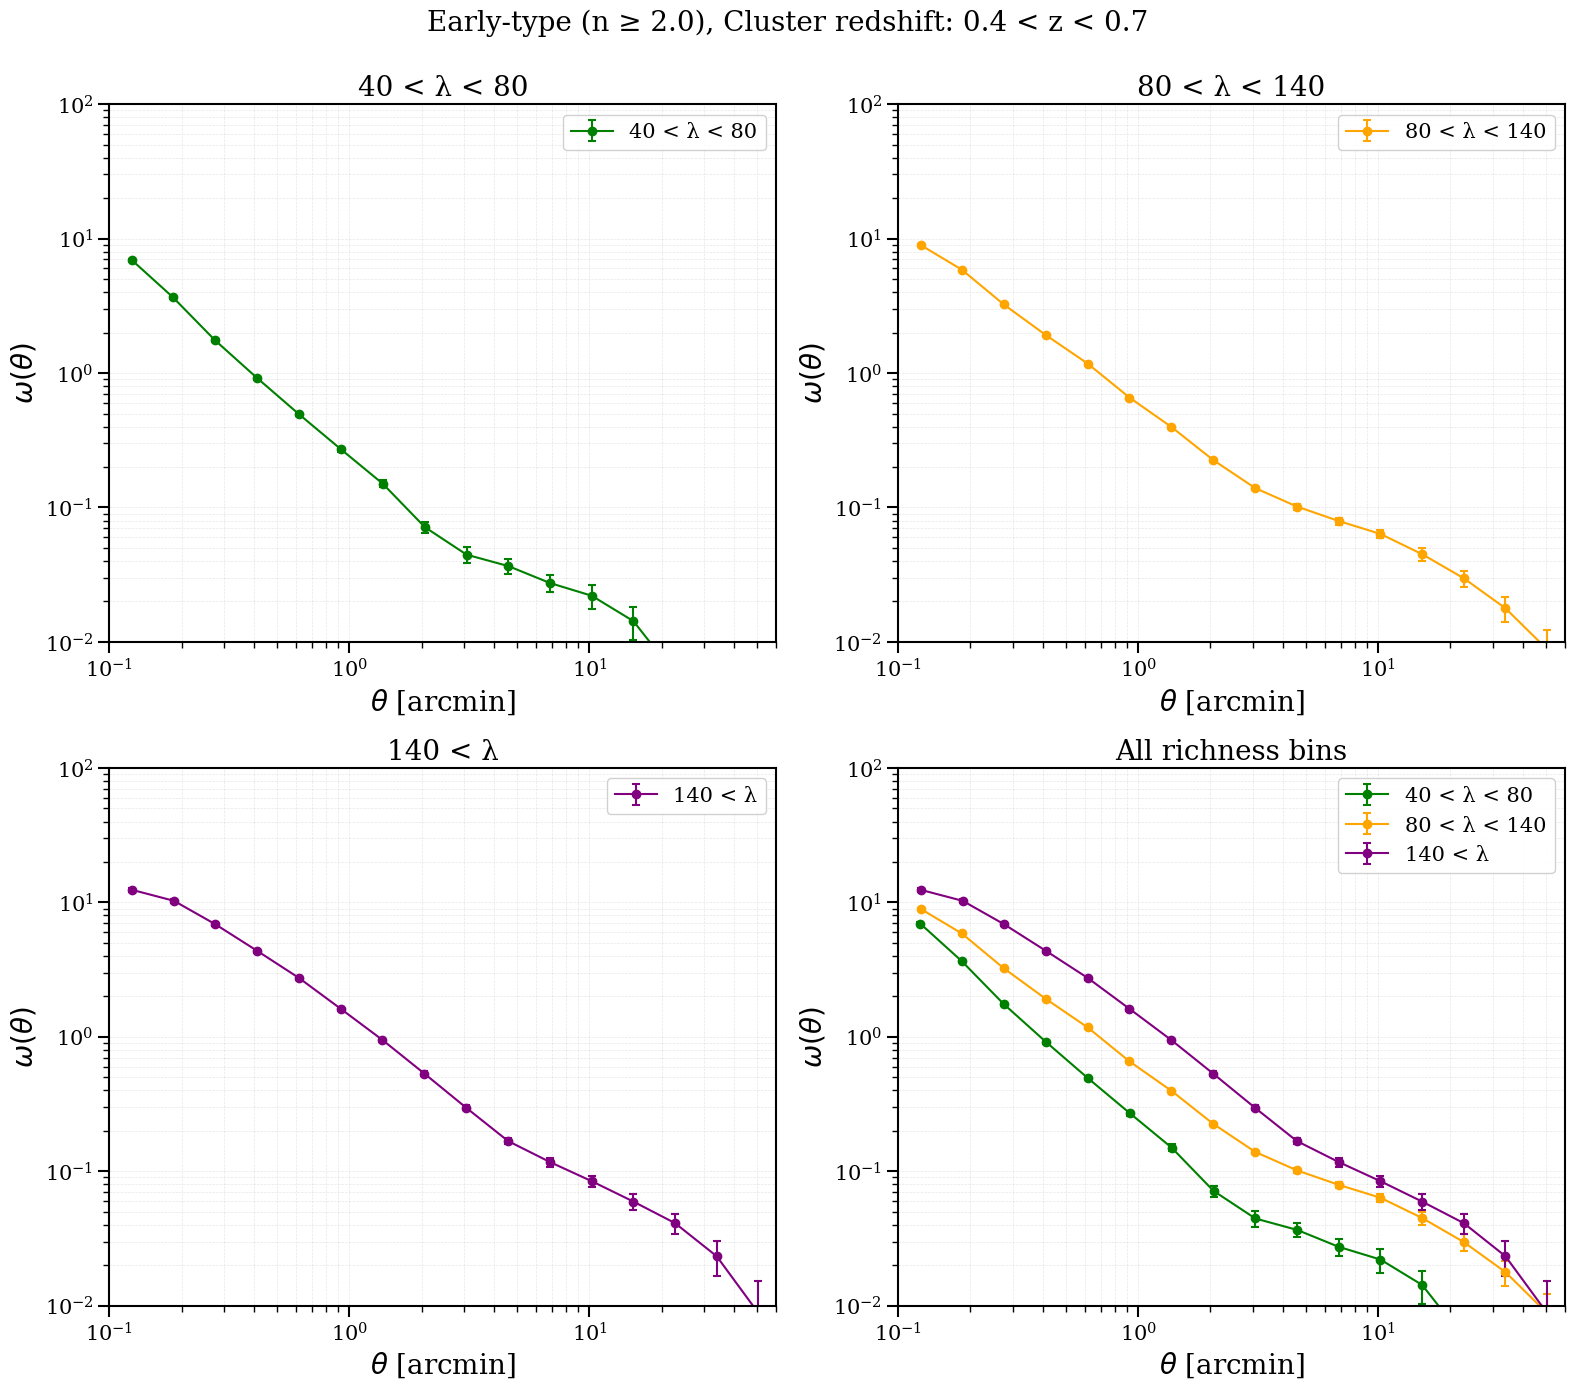

Saved: plot3_richness_comparison_late.png


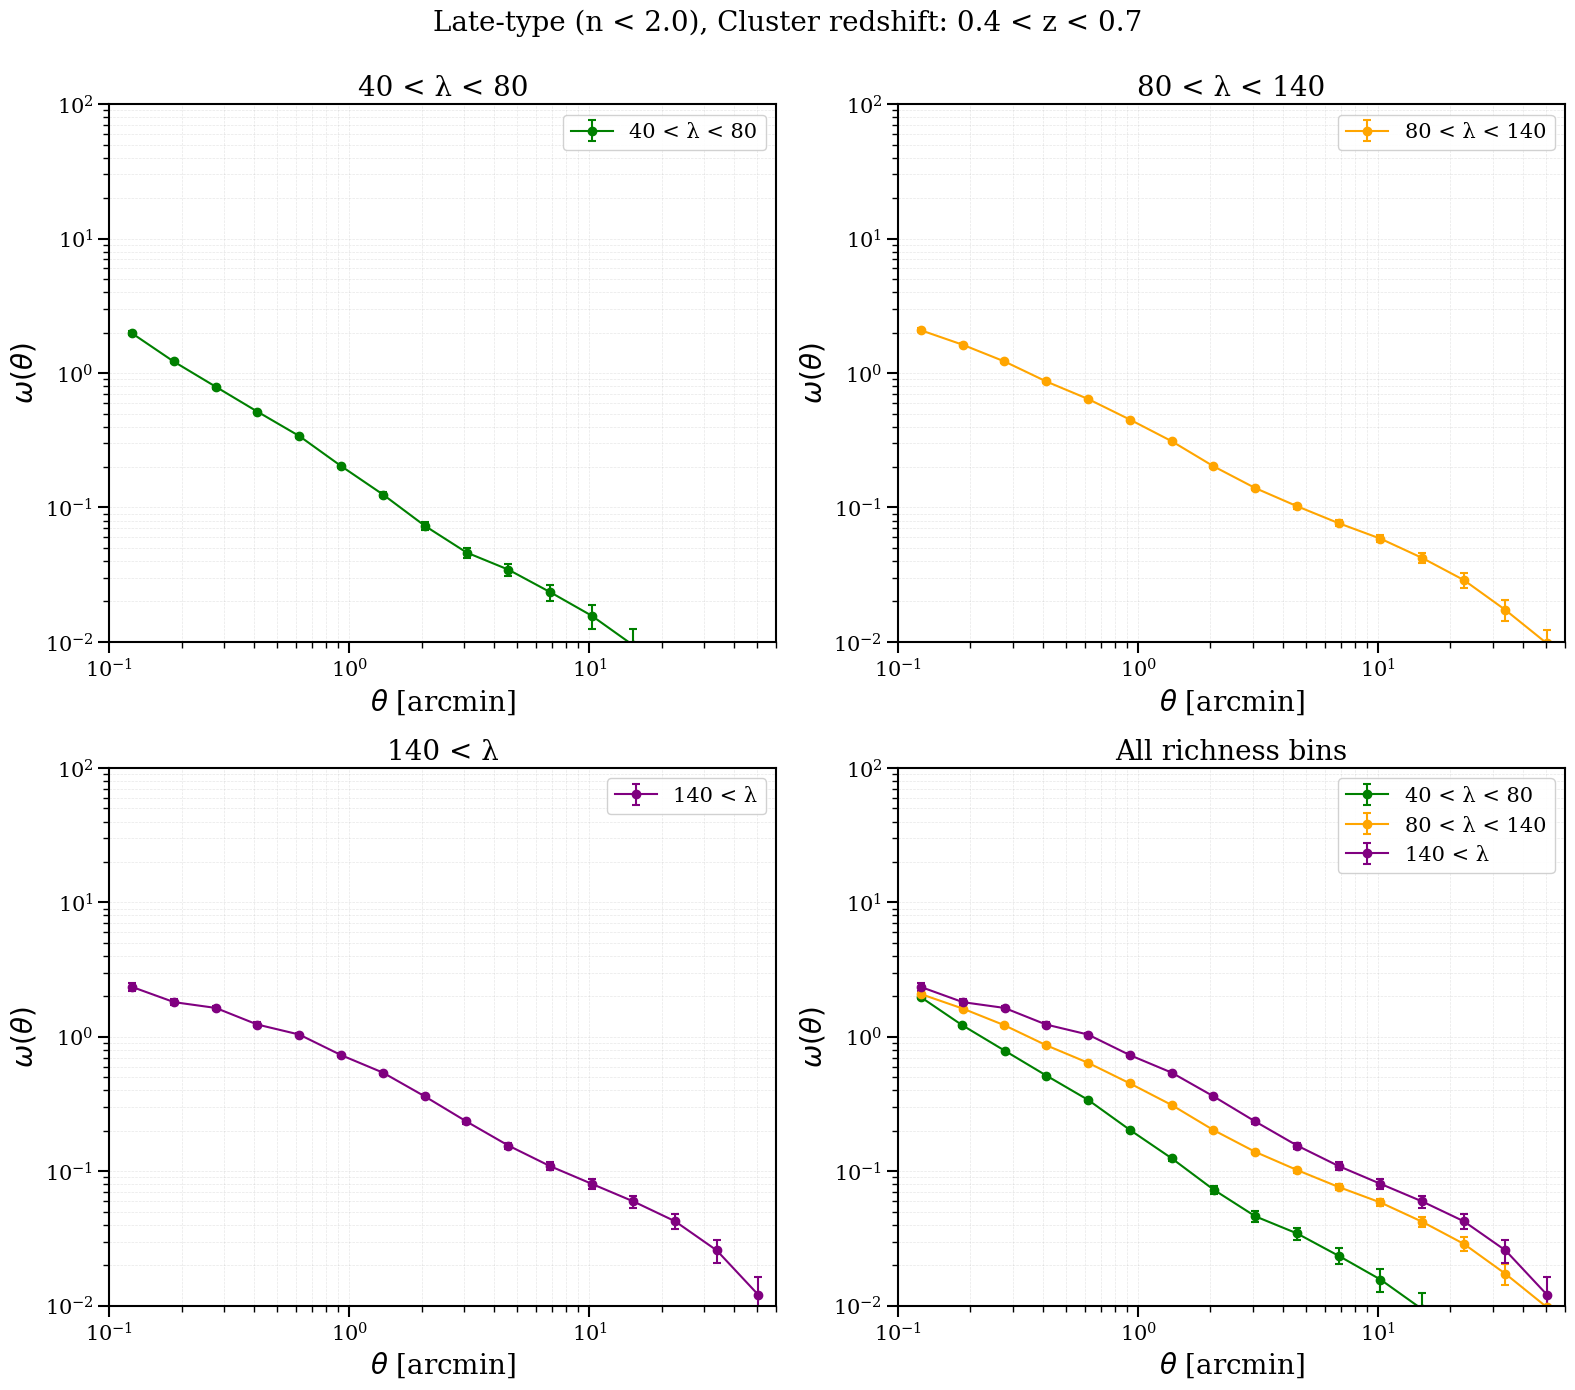

In [30]:
def plot_richness_comparison_grid(z_bin, gal_type='all', output_file=None):
    """
    Plot richness comparison in a 2x2 grid.
    
    Parameters
    ----------
    z_bin : tuple
        Redshift bin (z_min, z_max)
    gal_type : str
        Galaxy type: 'all', 'early', or 'late'
    output_file : str, optional
        Output filename
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    # Colors for richness bins
    richness_colors = ['green', 'orange', 'purple']
    
    # First 3 panels: individual richness bins
    for i, richness_bin in enumerate(richness_bins):
        ax = axes[i]
        
        # Find result file
        files = find_result_files(
            output_dirs[gal_type],
            z_cluster_bin=z_bin,
            z_galaxy_bin=z_bin,
            richness_bin=richness_bin
        )
        
        if len(files) == 0:
            continue
        
        # Load results
        results = load_clustering_result(files[0])
        
        # Plot
        plot_correlation_function(
            ax, results['r'], results['xi'], results['sigma_xi'],
            label=get_richness_bin_label(*richness_bin),
            color=richness_colors[i],
            marker='o', markersize=6
        )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        ax.set_title(get_richness_bin_label(*richness_bin))
    
    # 4th panel: all richness bins together
    ax = axes[3]
    for i, richness_bin in enumerate(richness_bins):
        # Find result file
        files = find_result_files(
            output_dirs[gal_type],
            z_cluster_bin=z_bin,
            z_galaxy_bin=z_bin,
            richness_bin=richness_bin
        )
        
        if len(files) == 0:
            continue
        
        # Load results
        results = load_clustering_result(files[0])
        
        # Plot
        plot_correlation_function(
            ax, results['r'], results['xi'], results['sigma_xi'],
            label=get_richness_bin_label(*richness_bin),
            color=richness_colors[i],
            marker='o', markersize=6
        )
    
    # Format 4th panel
    format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
    ax.set_title('All richness bins')
    
    # Overall title
    title = f"{get_galaxy_type_label(gal_type)}, "
    title += f"Cluster redshift: {get_redshift_bin_label(*z_bin)}"
    fig.suptitle(title, fontsize=FONT_SIZE_MAJOR, y=0.995)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for each galaxy type
for gal_type in ['all', 'early', 'late']:
    plot_richness_comparison_grid(
        DEFAULT_Z_BIN,
        gal_type=gal_type,
        output_file=f'plot3_richness_comparison_{gal_type}.png'
    )

## Plot 4: Redshift Evolution - Three Panels (One per Galaxy Type)

Shows redshift evolution with 3 side-by-side panels (all, early, late types).

Saved: plot4_redshift_evolution_lambda40_80.png


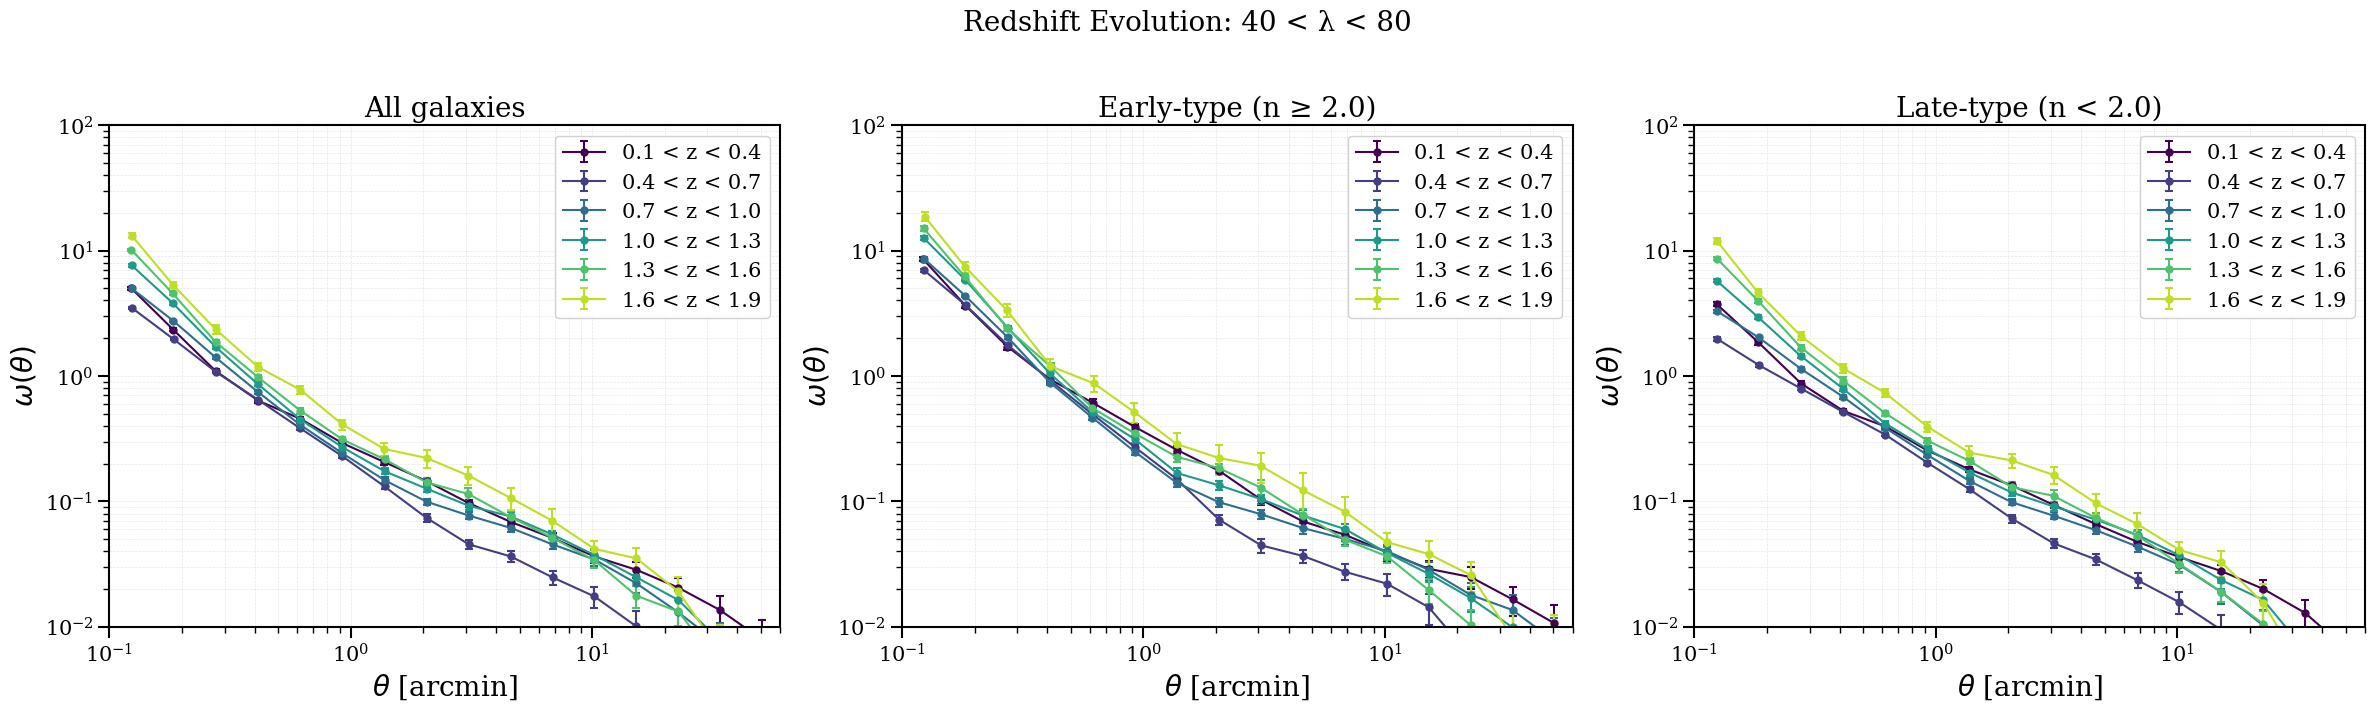

Saved: plot4_redshift_evolution_lambda80_140.png


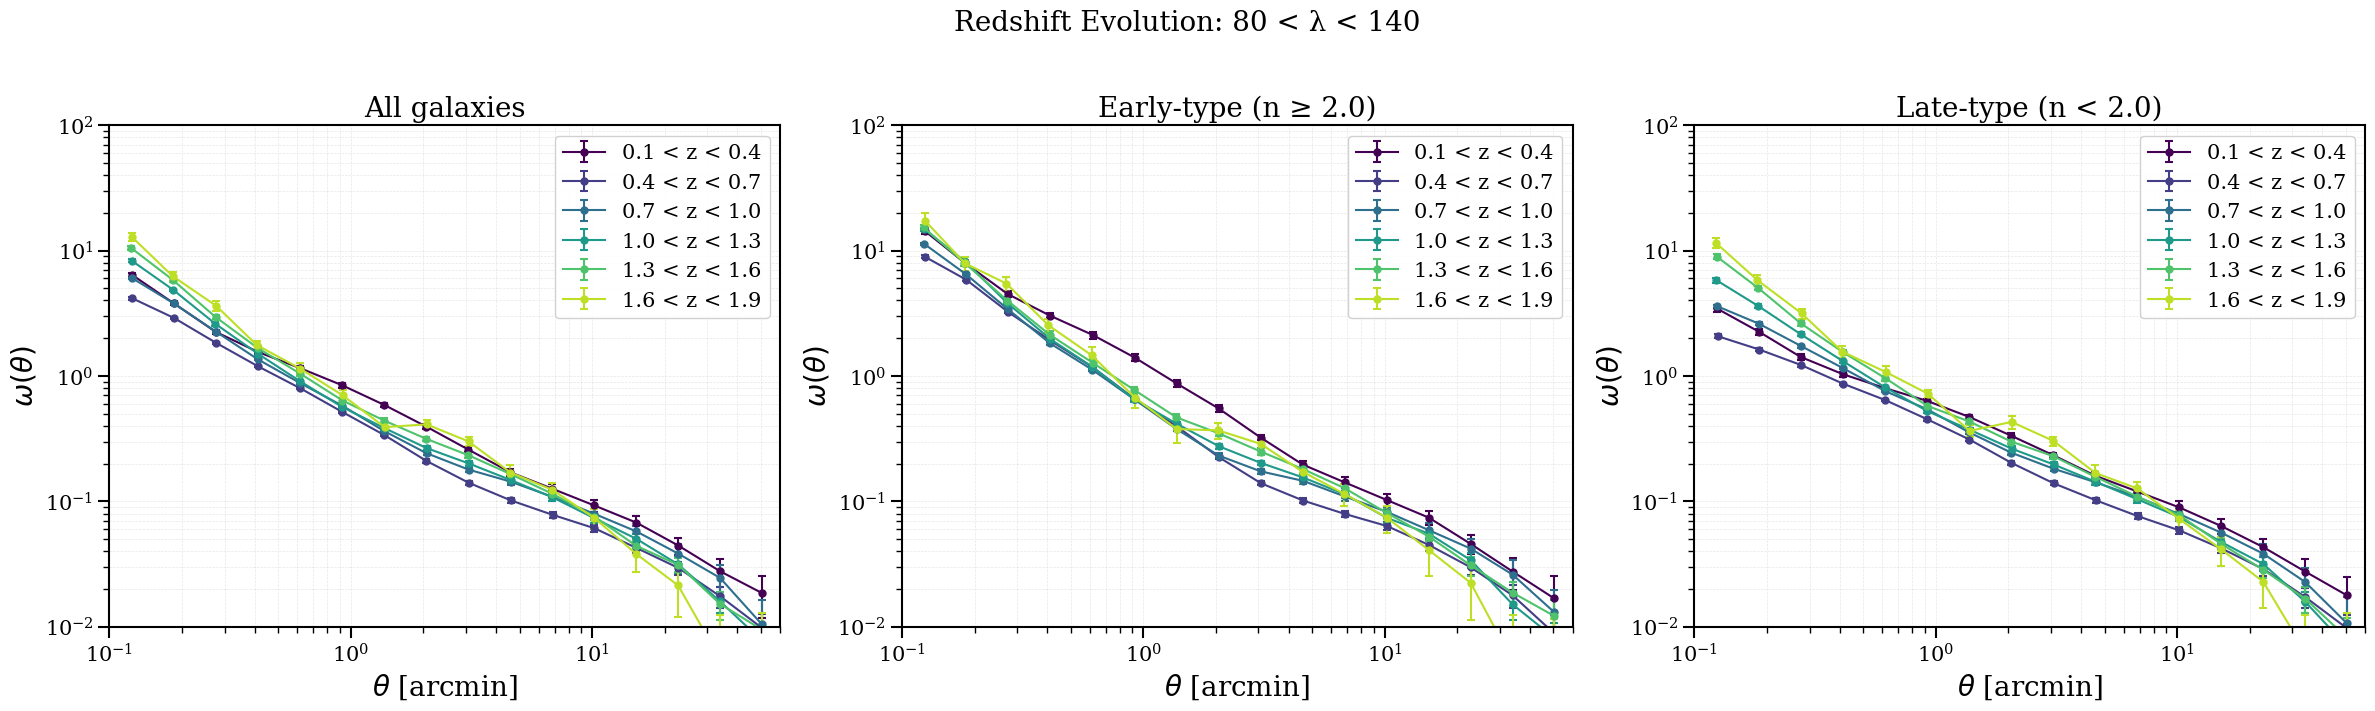

Saved: plot4_redshift_evolution_lambda140_450.png


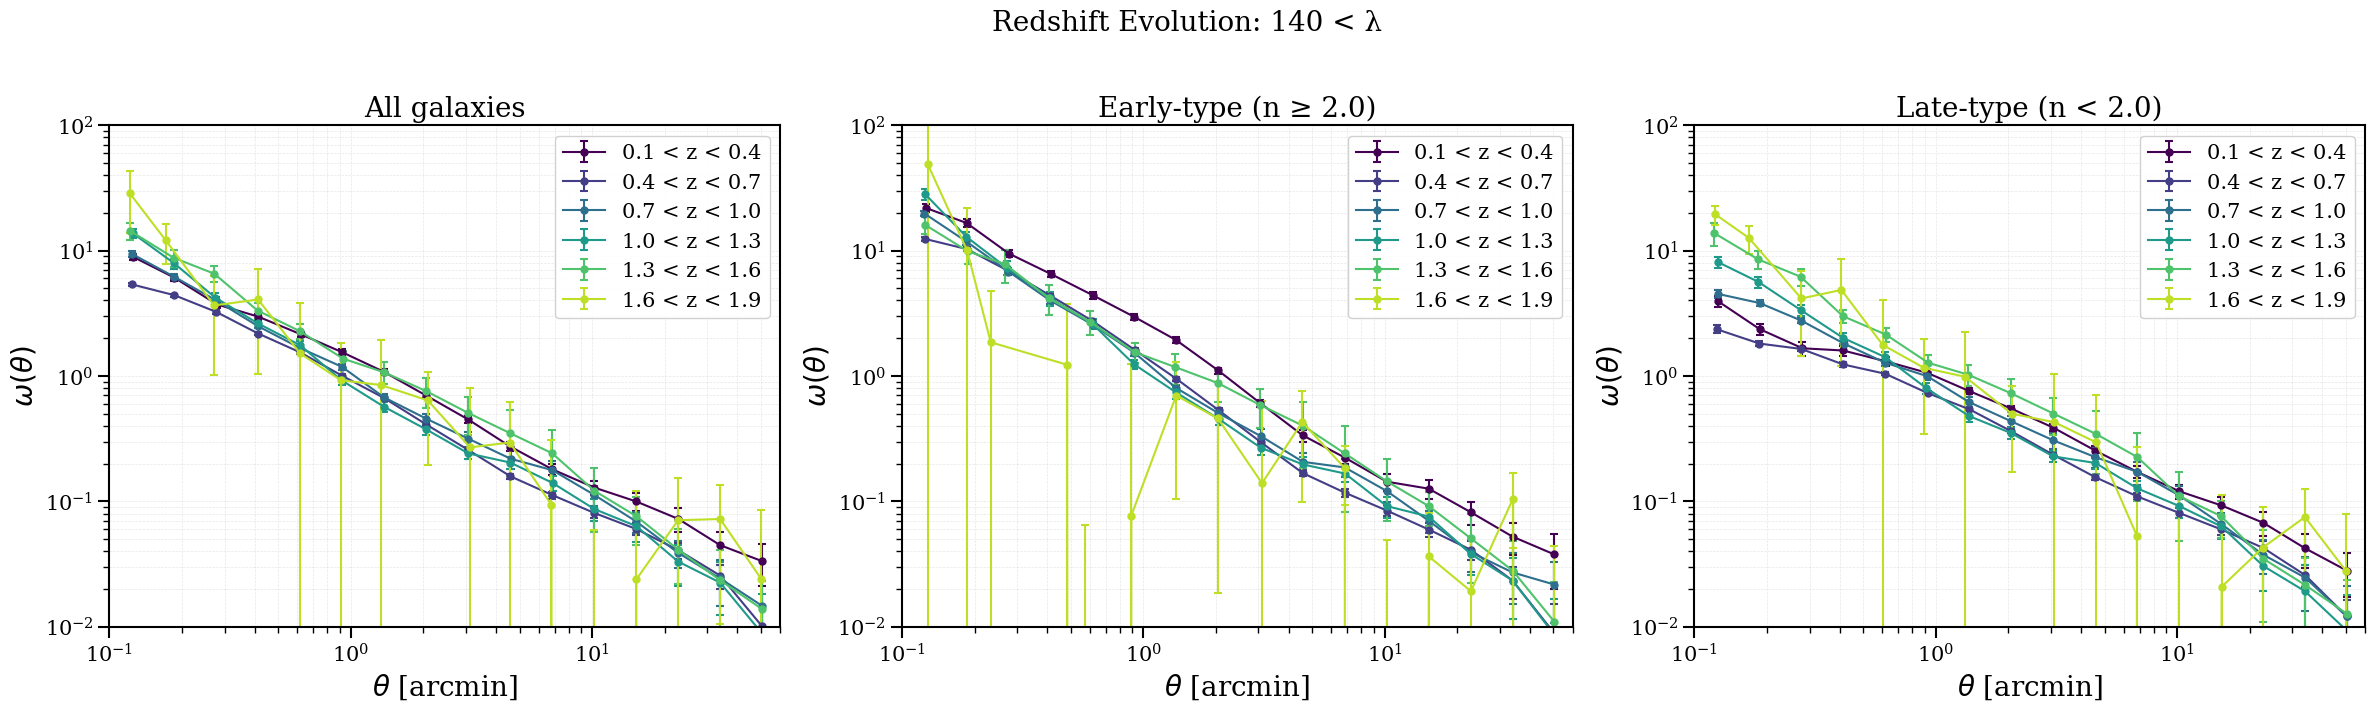


Note: To create redshift evolution plots without richness binning,
      modify output_dirs to point to outputs_rr2_redshift_* directories.


In [31]:
def plot_redshift_evolution(richness_bin=None, output_file=None):
    """
    Plot redshift evolution for all galaxy types in side-by-side panels.
    
    Parameters
    ----------
    richness_bin : tuple, optional
        Richness bin (lambda_min, lambda_max)
    output_file : str, optional
        Output filename
    """
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Colors for redshift bins
    z_colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshift_bins)))
    
    for j, gal_type in enumerate(['all', 'early', 'late']):
        ax = axes[j]
        
        # Plot each redshift bin
        for i, z_bin in enumerate(redshift_bins):
            # Find result file
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=z_bin,
                z_galaxy_bin=z_bin,
                richness_bin=richness_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot
            plot_correlation_function(
                ax, results['r'], results['xi'], results['sigma_xi'],
                label=get_redshift_bin_label(*z_bin),
                color=z_colors[i],
                marker='o', markersize=5
            )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        ax.set_title(get_galaxy_type_label(gal_type))
    
    # Overall title
    title = "Redshift Evolution"
    if richness_bin is not None:
        title += f": {get_richness_bin_label(*richness_bin)}"
    fig.suptitle(title, fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for each richness bin
for richness_bin in richness_bins:
    lambda_min, lambda_max = richness_bin
    plot_redshift_evolution(
        richness_bin=richness_bin,
        output_file=f'plot4_redshift_evolution_lambda{int(lambda_min)}_{int(lambda_max)}.png'
    )

# Also create one without richness binning (using redshift-only outputs)
# Note: This would require modifying output_dirs to point to redshift-only outputs
print("\nNote: To create redshift evolution plots without richness binning,")
print("      modify output_dirs to point to outputs_rr2_redshift_* directories.")

## Summary

All plots have been created and saved to the output directory.

In [32]:
print("\n" + "="*70)
print("PLOTTING COMPLETE")
print("="*70)
print(f"\nAll plots saved to: {PLOT_OUTPUT_DIR}")
print(f"\nGenerated plots:")
for plot_file in sorted(PLOT_OUTPUT_DIR.glob('*.png')):
    print(f"  - {plot_file.name}")


PLOTTING COMPLETE

All plots saved to: plots_galaxy_type_analysis

Generated plots:
  - plot1_type_comparison_single_z.png
  - plot2_type_comparison_all_richness.png
  - plot3_richness_comparison_all.png
  - plot3_richness_comparison_early.png
  - plot3_richness_comparison_late.png
  - plot4_redshift_evolution_lambda140_450.png
  - plot4_redshift_evolution_lambda40_80.png
  - plot4_redshift_evolution_lambda80_140.png
